# Student Performance Analysis using ML
* This project performs classification and regression on student dataset.

* Libraries

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("studentsPerformance.csv")
print(df.head())
print(df.info())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

In [11]:
# convert categorical variables into dummy variables
df = pd.get_dummies(df,drop_first=True)

# create a new column for classification of pass and fail based on math score
df["pass"]= df["math score"].apply(lambda x : 1 if x>=40 else 0)
df.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none,pass
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True,1
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False,1
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True,1
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True,1
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True,1


In [12]:
df.head()


,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none,pass
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True,1
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False,1
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True,1
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True,1
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True,1


# Classsification

In [13]:
x = df.drop(['pass'], axis=1)
y = df['pass']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
[[ 11   0]
 [  0 189]]


# Regression

In [15]:
X_reg = df.drop(['math score'], axis=1)
y_reg = df['math score']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred_reg = reg_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred_reg))
print("R2 Score:", r2_score(y_test, y_pred_reg))

MSE: 28.68234638566417
R2 Score: 0.8821297979042183


# Visualizaton

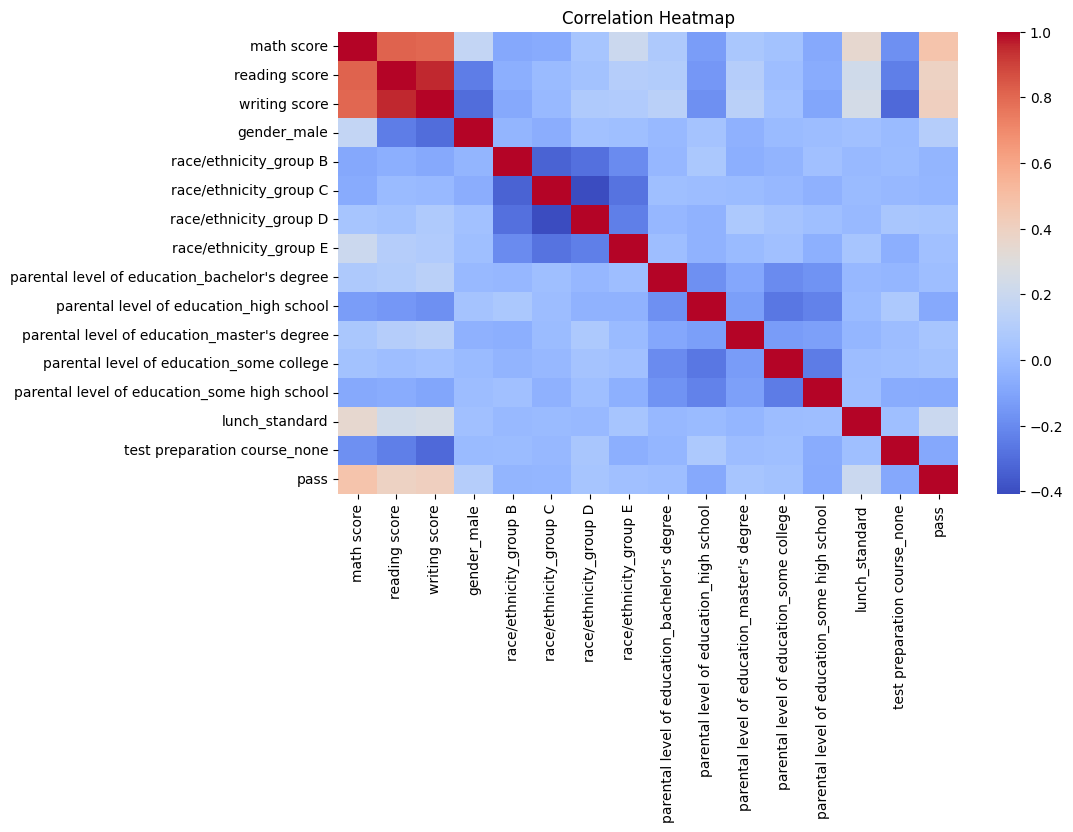

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

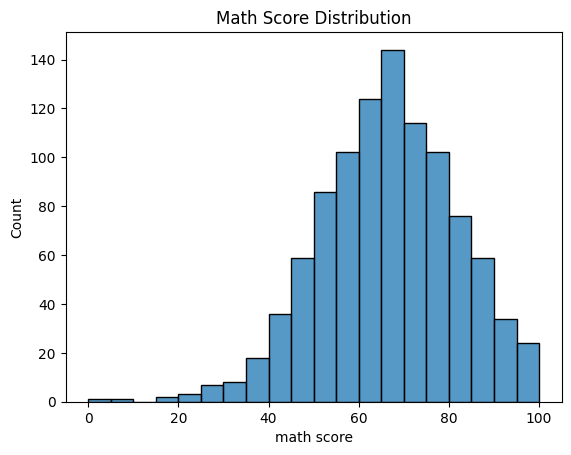

In [18]:
sns.histplot(df['math score'], bins=20)
plt.title("Math Score Distribution")
plt.show()

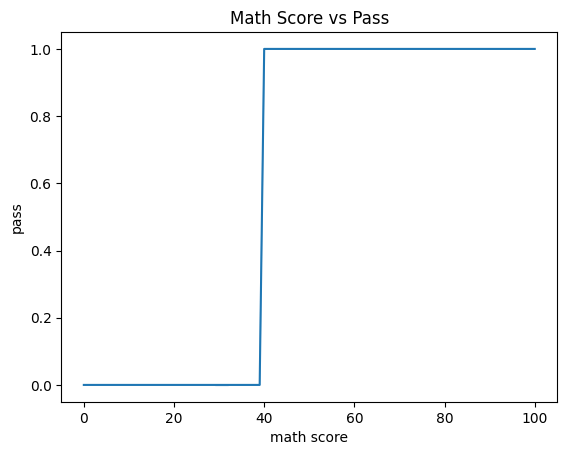

In [19]:
sns.lineplot(x='math score', y='pass', data=df)
plt.title("Math Score vs Pass")
plt.show()


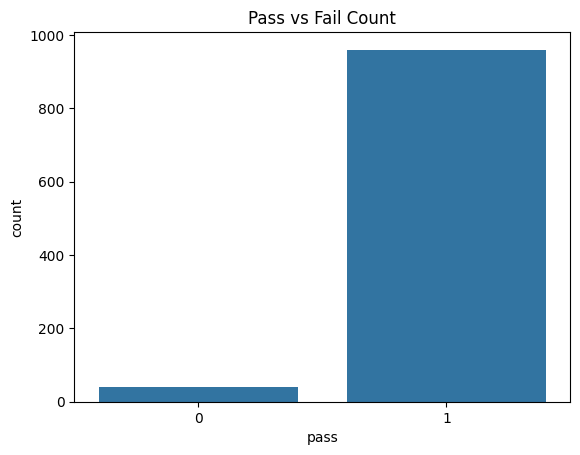

In [20]:
sns.countplot(x='pass', data=df)
plt.title("Pass vs Fail Count")
plt.show()

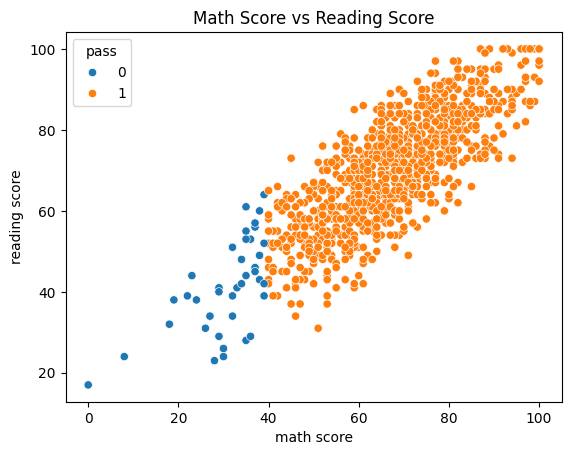

In [21]:
sns.scatterplot(x='math score', y='reading score', data=df, hue='pass')
plt.title("Math Score vs Reading Score")
plt.show()

# Decision tree
* decision trees are utilized to classify instances into different classes or categories based on input features.


In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
print("Decision Tree Accuracy:", dt.score(X_test, y_test))

Decision Tree Accuracy: 0.055


# Random forest
* Random Forest is an ensemble learning algorithm that combines many decision trees to make better predictions.

In [25]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

rf_reg.fit(x_train, y_train)

y_pred_reg = rf_reg.predict(x_test)

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred_reg))
print("R2 Score:", r2_score(y_test, y_pred_reg))

MSE: 1.0752650000000004
R2 Score: 0.9955811947477258


# K-Nearest Neighbour
* It predicts output based on the nearest data points.

In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.235
